In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [37]:
#pip install pygmt
#pip install pykrige
# pip install shapely

(52540.0, 52565.0)

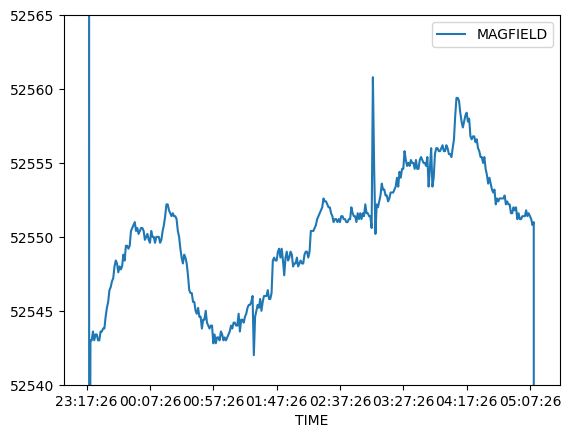

In [38]:
f1="Day1_Base.stn"
dfb1 = pd.read_csv(f1)
dfb1.plot("TIME","MAGFIELD")
plt.ylim(52540,52565)

<Axes: xlabel='TIME'>

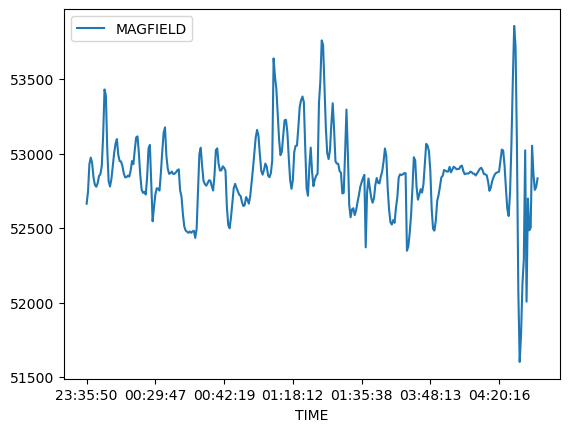

In [39]:
f2="Day1_Rover.stn"
dfr1 = pd.read_csv(f2)
dfr1.plot("TIME","MAGFIELD")
#plt.ylim(52540,52565)

In [40]:
dfb1['DATETIME'] = pd.to_datetime(dfb1['DATE'].astype(str) + ' ' + dfb1['TIME'].astype(str), format='%m/%d/%y %H:%M:%S')
dfr1['DATETIME'] = pd.to_datetime(dfr1['DATE'].astype(str) + ' ' + dfr1['TIME'].astype(str), format='%m/%d/%y %H:%M:%S')
common_start = min(dfb1['DATETIME'].iloc[0], dfr1['DATETIME'].iloc[0])
dfb1['MINUTES_SINCE_START'] = (dfb1['DATETIME'] - common_start).dt.total_seconds() / 60.0
dfr1['MINUTES_SINCE_START'] = (dfr1['DATETIME'] - common_start).dt.total_seconds() / 60.0

#dfr1.plot("MINUTES_SINCE_START","MAGFIELD")
#dfb1.plot("MINUTES_SINCE_START","MAGFIELD")

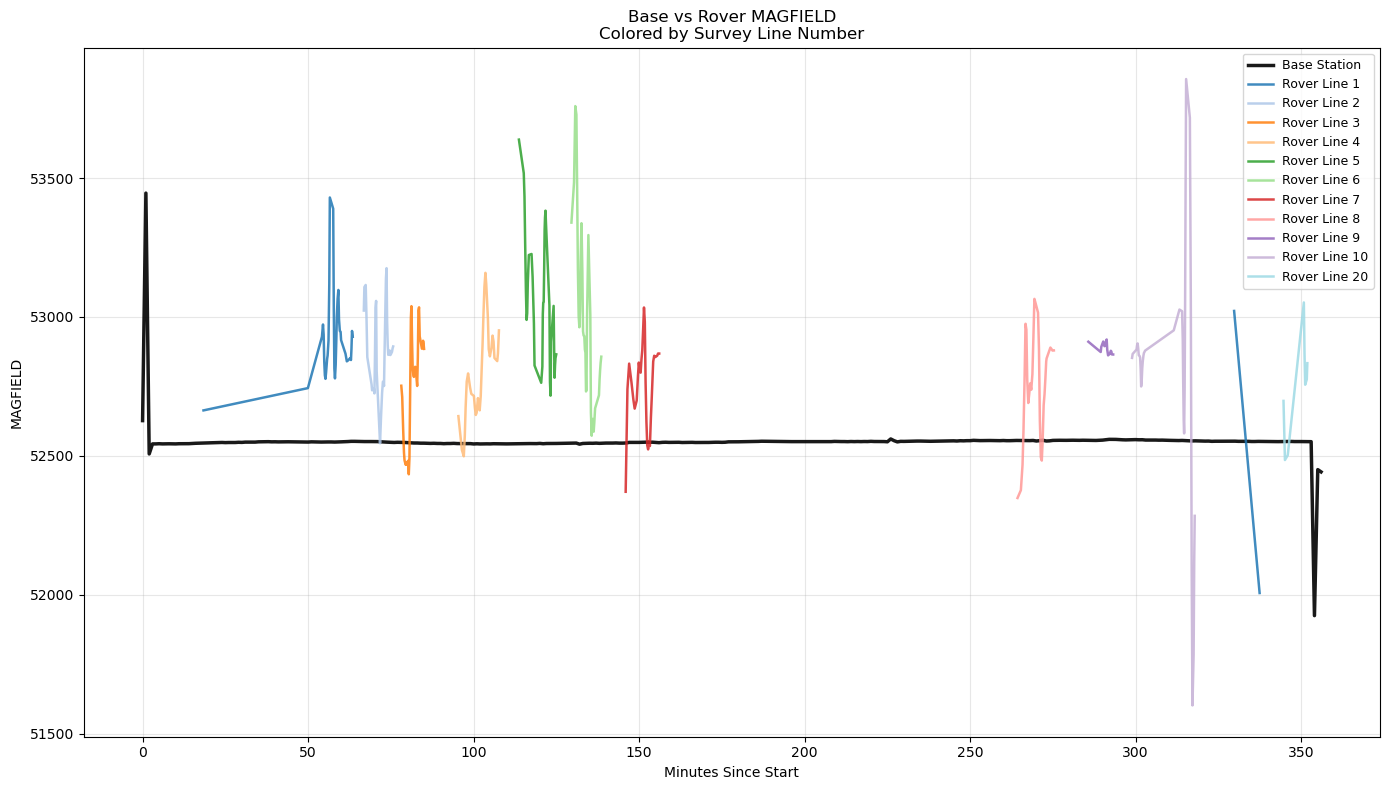

In [41]:
# Assuming dfb1 and dfr1 already have DATETIME and MINUTES_SINCE_START
# (from the previous corrected datetime parsing)

# Plot setup
plt.figure(figsize=(14, 8))

# 1. Plot Base station (single line, usually in black or gray)
plt.plot(dfb1['MINUTES_SINCE_START'], 
         dfb1['MAGFIELD'], 
         label='Base Station', 
         color='black', 
         linewidth=2.5, 
         alpha=0.9)

# 2. Plot Rover lines colored by LINE number
# Use a colormap that works well for sequential lines
cmap = plt.get_cmap('tab20')   # good for up to 20 different lines

for line_id in sorted(dfr1['LINE'].unique()):
    line_data = dfr1[dfr1['LINE'] == line_id]
    
    plt.plot(line_data['MINUTES_SINCE_START'], 
             line_data['MAGFIELD'], 
             label=f'Rover Line {line_id}',
             color=cmap((line_id-1) % 20),   # cycle colors nicely
             linewidth=1.8,
             alpha=0.85)

plt.xlabel('Minutes Since Start')
plt.ylabel('MAGFIELD')
plt.title('Base vs Rover MAGFIELD\nColored by Survey Line Number')
plt.grid(True, alpha=0.3)

# Improve legend (only show first 10 lines if many)
handles, labels = plt.gca().get_legend_handles_labels()
if len(labels) > 12:
    plt.legend(handles[:12], labels[:12], loc='best', fontsize=9)
else:
    plt.legend(loc='best')

plt.tight_layout()
plt.show()

In [42]:
f1 = "Day1_Base.stn"
f2 = "Day1_Rover.stn"

dfb1 = pd.read_csv(f1)
dfr1 = pd.read_csv(f2)

# Convert TIME to datetime
dfb1['DATETIME'] = pd.to_datetime(dfb1['DATE'].astype(str) + ' ' + dfb1['TIME'].astype(str), format='%m/%d/%y %H:%M:%S')
dfr1['DATETIME'] = pd.to_datetime(dfr1['DATE'].astype(str) + ' ' + dfr1['TIME'].astype(str), format='%m/%d/%y %H:%M:%S')

# Set TIME as index
dfb1 = dfb1.set_index('DATETIME')
dfr1 = dfr1.set_index('DATETIME')

# Drop the first row from both (while keeping DatetimeIndex)
dfb1 = dfb1.iloc[1:]
dfr1 = dfr1.iloc[1:]

combined_index = dfb1.index.union(dfr1.index)
base_aligned = dfb1.reindex(combined_index)
numeric_cols = base_aligned.select_dtypes(include=['number']).columns
base_interp_full = base_aligned.copy()
base_interp_full[numeric_cols] = base_aligned[numeric_cols].interpolate(method='time')
base_interp = base_interp_full.reindex(dfr1.index)

dfr1['MAGFIELD_corrected'] = dfr1['MAGFIELD'] - base_interp['MAGFIELD']

#print(base_interp)

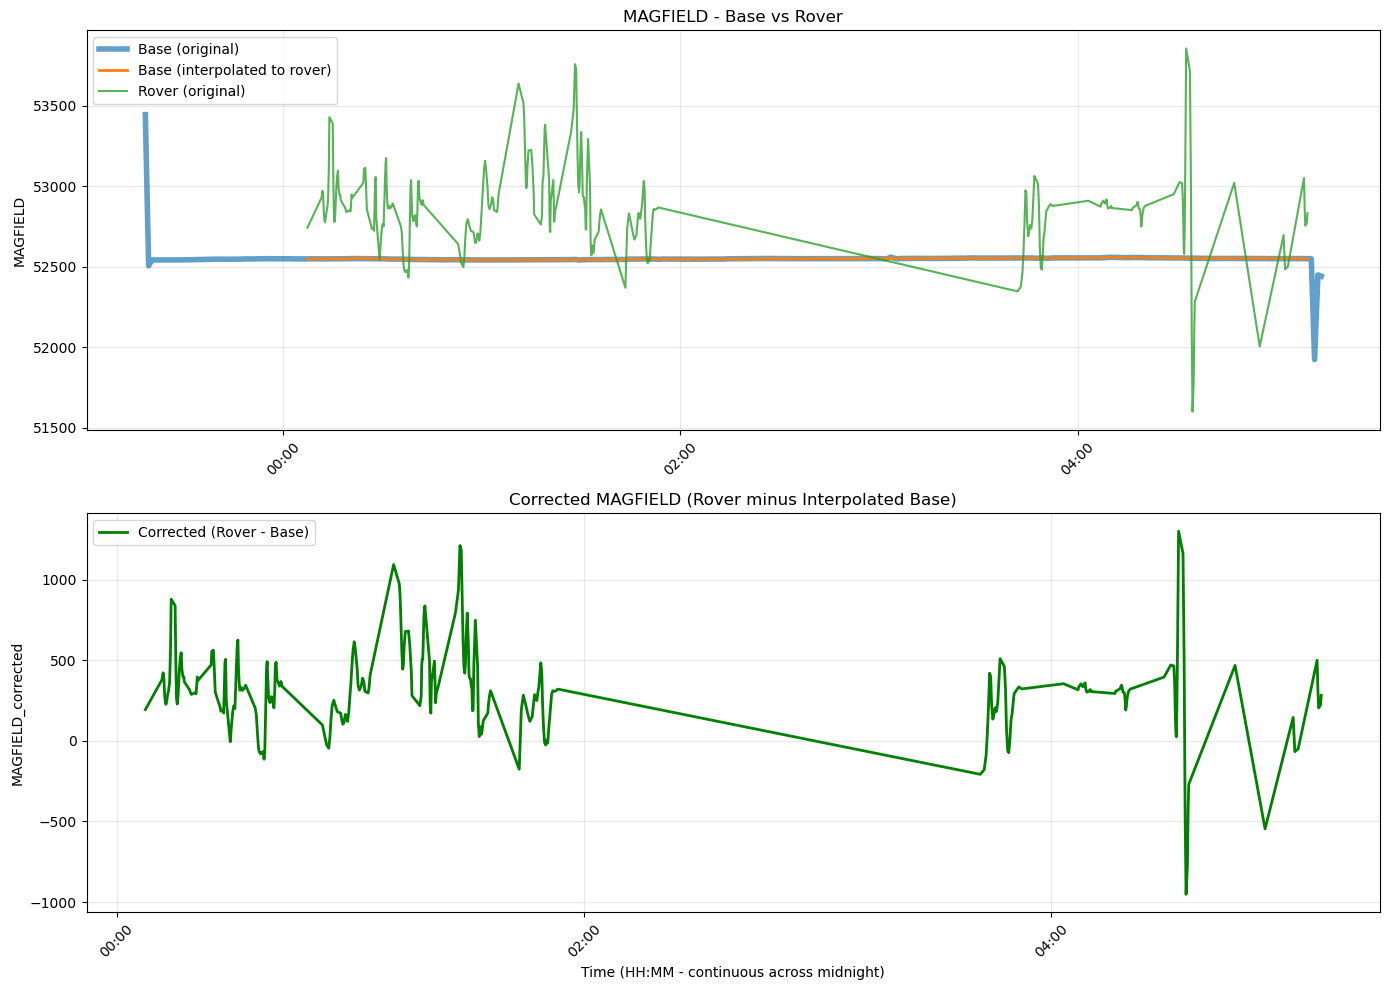

In [43]:
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

plt.figure(figsize=(14, 10))

# Top plot: Base + Rover + Interpolated Base
ax1 = plt.subplot(2, 1, 1)
ax1.plot(dfb1.index, dfb1['MAGFIELD'], label='Base (original)', alpha=0.7, linewidth=4)
ax1.plot(base_interp.index, base_interp['MAGFIELD'], '-', label='Base (interpolated to rover)', linewidth=2)
ax1.plot(dfr1.index, dfr1['MAGFIELD'],label='Rover (original)', alpha=0.8)

ax1.set_title('MAGFIELD - Base vs Rover')
ax1.set_ylabel('MAGFIELD')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Format x-axis as rolling 24-hour time (HH:MM only, continuous across days)
ax1.xaxis.set_major_formatter(DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))   # show tick every 2 hours (adjust as needed)
ax1.tick_params(axis='x', rotation=45)

# Bottom plot: Corrected Rover
ax2 = plt.subplot(2, 1, 2)
ax2.plot(dfr1.index, dfr1['MAGFIELD_corrected'], 'g-', label='Corrected (Rover - Base)', linewidth=2)

ax2.set_title('Corrected MAGFIELD (Rover minus Interpolated Base)')
ax2.set_xlabel('Time (HH:MM - continuous across midnight)')
ax2.set_ylabel('MAGFIELD_corrected')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Same rolling 24h format on bottom axis
ax2.xaxis.set_major_formatter(DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [44]:
dfr1.to_csv("corrected_day1_rover.csv")

In [45]:
import pandas as pd
import numpy as np

# Read the corrected file
df = pd.read_csv("corrected_day1_rover.csv")
df = df[df['LINE'] <= 8].copy()
# Reset index if DATETIME became the index when saving
if 'DATETIME' in df.columns:
    df['DATETIME'] = pd.to_datetime(df['DATETIME'])
else:
    # If index was saved as unnamed column
    df = pd.read_csv("corrected_day1_rover.csv", parse_dates=['DATETIME'] if 'DATETIME' in df.columns else None)

print(f"Loaded {len(df)} readings from corrected_day1_rover.csv")


# Count points per line
line_counts = df['LINE'].value_counts().sort_index()
print("\nPoints per line:")
print(line_counts)

# === Create X and Y position columns ===
# X = Line number (each line is a new X position)
# Y = distance along the line from 0m to 65m

df['X'] = (df['LINE']-1.0)*5.0   # X coordinate = line number

# For each line, create Y from 0 to 65 meters evenly spaced
df['Y'] = 0.0

for line_id in df['LINE'].unique():
    mask = df['LINE'] == line_id
    n_points = mask.sum()
    
    #y_positions = np.arange(n_points) * 2.0
    y_positions = np.linspace(0,65,n_points)
    df.loc[mask, 'Y'] = y_positions

cols = ['DATETIME', 'LINE', 'X', 'Y', 'MAGFIELD', 'MAGFIELD_corrected']
other_cols = [c for c in df.columns if c not in cols]
df = df[cols + other_cols]

print("\nFirst 10 rows with X/Y coordinates:")
print(df.head(100))

# Save the gridded version
df.to_csv("corrected_day1_rover_with_xy.csv", index=False)
print("\nSaved as 'corrected_day1_rover_with_xy.csv'")

Loaded 263 readings from corrected_day1_rover.csv

Points per line:
LINE
1    34
2    33
3    34
4    34
5    33
6    34
7    30
8    31
Name: count, dtype: int64

First 10 rows with X/Y coordinates:
              DATETIME  LINE     X          Y  MAGFIELD  MAGFIELD_corrected  \
0  2026-03-28 00:07:22     1   0.0   0.000000   52743.8          194.186667   
1  2026-03-28 00:11:37     1   0.0   1.969697   52928.8          379.126667   
2  2026-03-28 00:11:56     1   0.0   3.939394   52972.8          423.000000   
3  2026-03-28 00:12:08     1   0.0   5.909091   52935.6          385.720000   
4  2026-03-28 00:12:19     1   0.0   7.878788   52838.6          288.646667   
..                 ...   ...   ...        ...       ...                 ...   
95 2026-03-28 00:41:09     3  10.0  55.151515   52930.0          384.230000   
96 2026-03-28 00:41:49     3  10.0  57.121212   52885.8          340.200000   
97 2026-03-28 00:42:00     3  10.0  59.090909   52887.2          341.600000   
98 2026-03

Loaded 263 readings with X/Y positions
Lines detected: 8


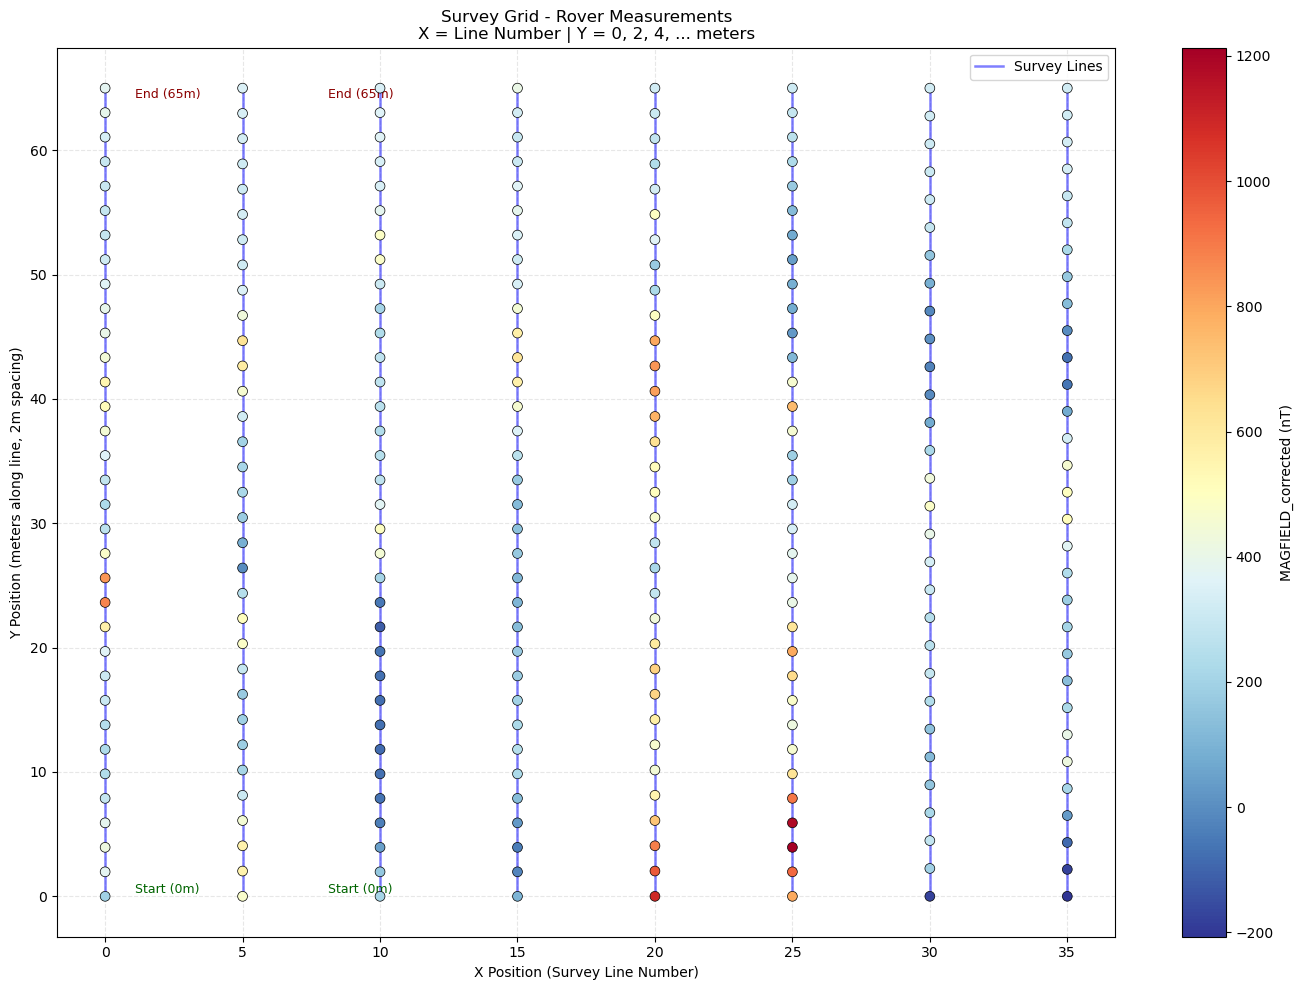


Summary of positions:
         X    Y            
     first  min   max count
LINE                       
1      0.0  0.0  65.0    34
2      5.0  0.0  65.0    33
3     10.0  0.0  65.0    34
4     15.0  0.0  65.0    34
5     20.0  0.0  65.0    33
6     25.0  0.0  65.0    34
7     30.0  0.0  65.0    30
8     35.0  0.0  65.0    31


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the file that already has X and Y columns
df = pd.read_csv("corrected_day1_rover_with_xy.csv")

# Ensure types are correct
df['LINE'] = df['LINE'].astype(int)
if 'DATETIME' in df.columns:
    df['DATETIME'] = pd.to_datetime(df['DATETIME'])

print(f"Loaded {len(df)} readings with X/Y positions")
print(f"Lines detected: {df['LINE'].nunique()}")

# ====================== SURVEY GRID VISUALIZATION ======================
plt.figure(figsize=(14, 10))

# Plot lines as light blue paths
for line_id in sorted(df['LINE'].unique()):
    line_data = df[df['LINE'] == line_id].sort_values('Y')   # ensure order along line
    plt.plot(line_data['X'], line_data['Y'], 'b-', alpha=0.5, linewidth=1.8, 
             label='Survey Lines' if line_id == df['LINE'].min() else "")

# Plot individual measurement points colored by corrected MAGFIELD
scatter = plt.scatter(df['X'], df['Y'], 
                      c=df['MAGFIELD_corrected'], 
                      cmap='RdYlBu_r',      # red = high, blue = low (common for mag data)
                      s=50, 
                      edgecolors='black', 
                      linewidth=0.5,
                      zorder=5)

plt.colorbar(scatter, label='MAGFIELD_corrected (nT)')

plt.xlabel('X Position (Survey Line Number)')
plt.ylabel('Y Position (meters along line, 2m spacing)')
plt.title('Survey Grid - Rover Measurements\n'
          'X = Line Number | Y = 0, 2, 4, ... meters')

plt.grid(True, alpha=0.3, linestyle='--')

# Add Y=0 and approximate end labels on first and last line
first_line = df['LINE'].min()
last_line = df['LINE'].max()

for lx in [first_line, last_line]:
    line_data = df[df['LINE'] == lx]
    if not line_data.empty:
        plt.text(lx + 0.1, 0, 'Start (0m)', fontsize=9, color='darkgreen', va='bottom')
        max_y = line_data['Y'].max()
        plt.text(lx + 0.1, max_y, f'End ({max_y:.0f}m)', fontsize=9, color='darkred', va='top')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Quick summary
print("\nSummary of positions:")
print(df.groupby('LINE')[['X', 'Y']].agg({'X': 'first', 'Y': ['min', 'max', 'count']}))

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'spherical' Variogram Model
Partial Sill: 19230.830248853665
Full Sill: 65174.97000087937
Range: 64.67041338283045
Nugget: 45944.13975202571 

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



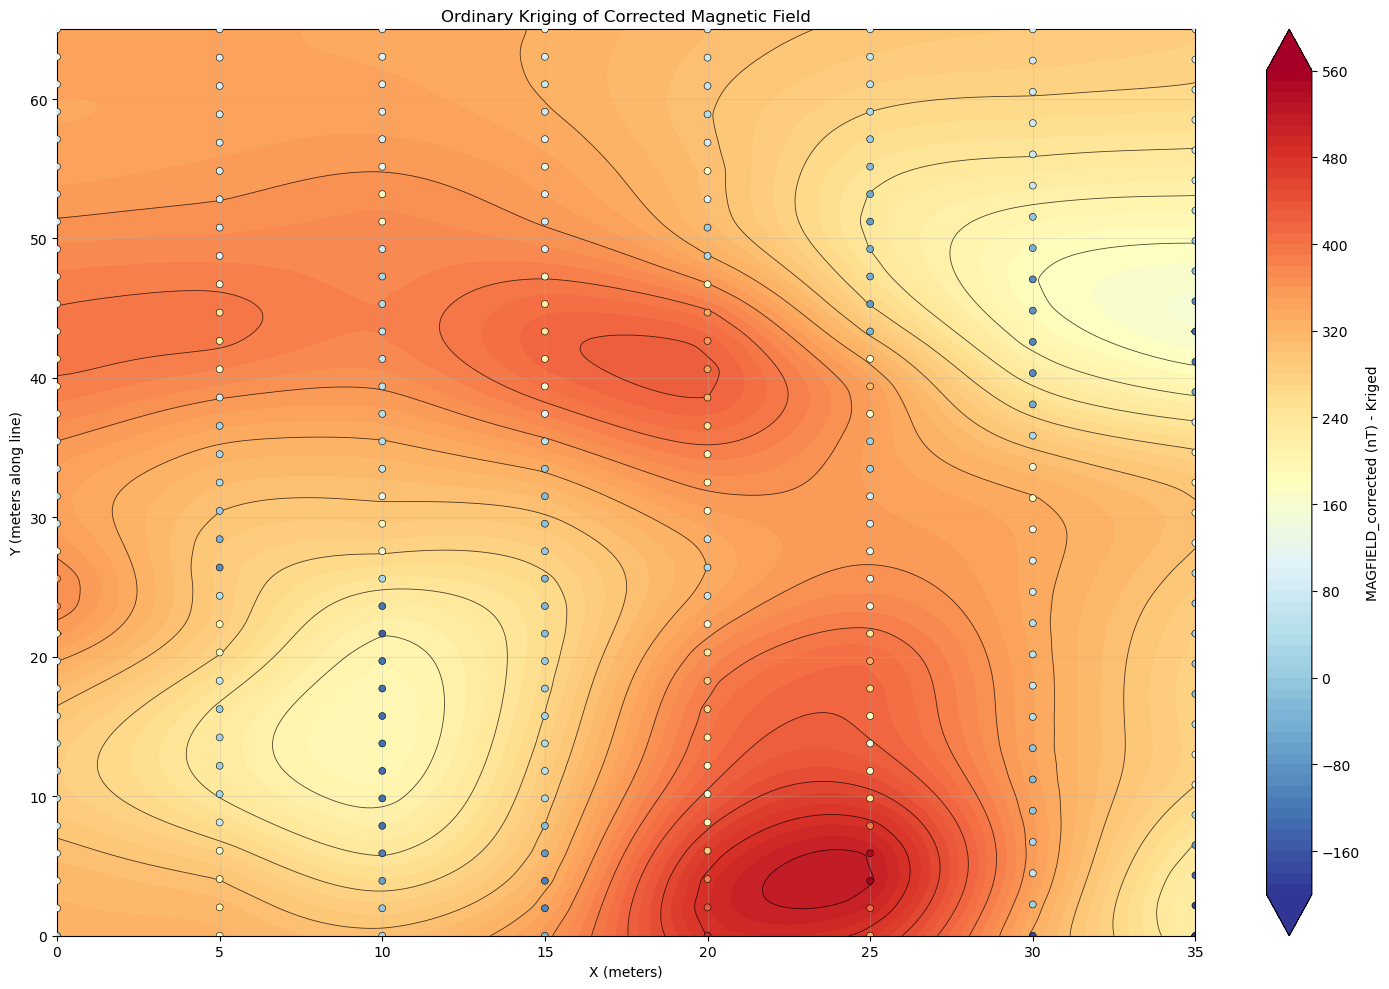

In [47]:
from pykrige.ok import OrdinaryKriging
x = df['X'].to_numpy()
y = df['Y'].to_numpy()
z = df['MAGFIELD_corrected'].to_numpy()
ok = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',   # Good default for magnetic data
    # variogram_model='gaussian',  # Try this alternative if needed
    verbose=True,
    enable_plotting=False
)

# Define grid
grid_x = np.linspace(x.min(), x.max(), 250)
grid_y = np.linspace(y.min(), y.max(), 250)

# Execute kriging
z_kriged, z_variance = ok.execute('grid', grid_x, grid_y)

plt.figure(figsize=(15, 10))

cf = plt.contourf(grid_x, grid_y, z_kriged, levels=80, cmap='RdYlBu_r', extend='both')
plt.contour(grid_x, grid_y, z_kriged, levels=25, colors='black', linewidths=0.6, alpha=0.7)

# Original points
plt.scatter(x, y, c=z, s=25, edgecolors='k', linewidth=0.4, cmap='RdYlBu_r', zorder=5)

plt.colorbar(cf, label='MAGFIELD_corrected (nT) - Kriged')
plt.xlabel('X (meters)')
plt.ylabel('Y (meters along line)')
plt.title('Ordinary Kriging of Corrected Magnetic Field')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
import rasterio
from rasterio.transform import Affine


In [49]:
# Enter x any y pixel numbers here (this is what Kriging is making)
mx=400
my=400

#Enter your coordinates of the nw,ne,se and sw corners here.

nw = np.array([503365.077, 6964946.459])   # local (0, 0)
ne = np.array([503427.687, 6964929.013])   # local (0, local_max_y)
se = np.array([503413.998, 6964896.691])   # local (local_max_x, local_max_y)
sw = np.array([503353.190, 6964914.007])   # local (local_max_x, 0)


# ====================== 1. Load data ======================
df = pd.read_csv("corrected_day1_rover_with_xy.csv")

x_local = df['X'].to_numpy()
y_local = df['Y'].to_numpy()
z = df['MAGFIELD_corrected'].to_numpy()

# ====================== 2. Ordinary Kriging ======================
ok = OrdinaryKriging(x_local, y_local, z, variogram_model='spherical', verbose=False)

grid_x = np.linspace(0, local_max_x, mx)
grid_y = np.linspace(0, local_max_y, my)
z_kriged, _ = ok.execute('grid', grid_x, grid_y)

# ====================== 3. Exact corner mapping to grid coordinates ======================

# Vectors
vec_x = sw - nw
vec_y = ne - nw

# Build Affine transform using ACTUAL data extents
a = vec_x[0] / mx
b = vec_y[0] / my
c = nw[0]

d = vec_x[1] / mx
e = vec_y[1] / my
f = nw[1]

transform = Affine(a, b, c, d, e, f)

# ====================== 4. Export GeoTIFF ======================
with rasterio.open(
    "magnetic_corrected_kriged_aligned.tif",
    'w',
    driver='GTiff',
    height=z_kriged.shape[0],
    width=z_kriged.shape[1],
    count=1,
    dtype=z_kriged.dtype,
    crs='EPSG:7856',           # GDA2020 / MGA Zone 56
    transform=transform,
    nodata=np.nan
) as dst:
    dst.write(z_kriged, 1)
